11751sigs_diwasp-a	Signature1000	December 09, 2024	March 10, 2025	
Significant wave height, 
Dominant (peak) wave period, 
Average wave period, 
Mean wave direction, 
Dominant wave direction (from, relative to true north), 
Direction (from, relative to true north),
Directional wave energy spectrum, 
Frequency (non-directional) wave energy spectrum from pyDIWASP, 
Total water depth, 
Water level NAVD88, 


In [5]:
import xarray as xr
import os
print(os.getcwd())
# dirpath = 'Marconi_wave-data'
# os.chdir(dirpath)
# ds = xr.open_dataset("11751sigs-a.nc")
ds = xr.open_dataset("Marconi_wave-data/11751sigs_diwasp-a.nc")

print(ds.data_vars)

/home/cvolpano/PUVprocessing_usgs/nanopod/data
Data variables:
    wh_4061      (time) float64 17kB ...
    wp_peak      (time) float64 17kB ...
    wp_4060      (time) float64 17kB ...
    wvdir        (time) float64 17kB ...
    dwvdir       (time) float64 17kB ...
    wd_4062      (time) float64 17kB ...
    dspec        (time, frequency, direction) float64 804MB ...
    fspec        (time, frequency) float64 4MB ...
    diwasp_type  (time) <U3 26kB ...
    water_depth  (time) float64 17kB ...
    water_level  (time) float64 17kB ...


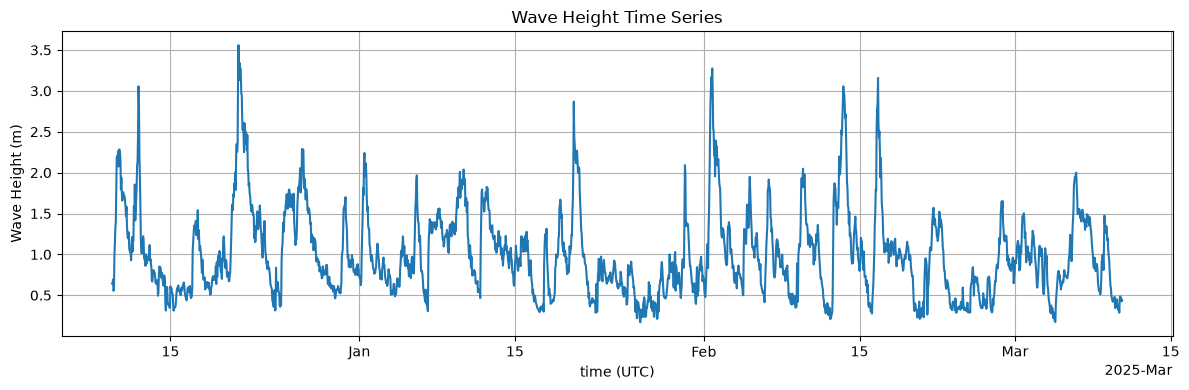

                      wh_4061    wp_peak  wvdir  water_level  water_depth
time                                                                     
2024-12-09 18:00:00  0.642796   5.361930   56.0    -0.529863    20.470444
2024-12-09 19:00:00  0.649011   5.361930   58.0    -0.101249    20.895550
2024-12-09 20:00:00  0.694649   5.148005   52.0     0.406779    21.411462
2024-12-09 21:00:00  0.554788   6.125574   84.0     0.803410    21.806536
2024-12-09 22:00:00  0.576353   5.594406   78.0     1.015799    22.019839
...                       ...        ...    ...          ...          ...
2025-03-10 11:00:00  0.487297  10.695187  100.0     0.685515    21.711144
2025-03-10 12:00:00  0.462033   9.876543  112.0     1.038775    22.061255
2025-03-10 13:00:00  0.463688   9.174312  110.0     1.190890    22.211176
2025-03-10 14:00:00  0.425186   7.561437  132.0     1.089469    22.113956
2025-03-10 15:00:00  0.438509  11.661808  100.0     0.753287    21.776592

[2182 rows x 5 columns]


In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import os 

# os.chdir(dirpath)
# ds = xr.open_dataset("11752sgt-a.nc")
ds = xr.open_dataset("Marconi_wave-data/11751sigs_diwasp-a.nc")
# ds = xr.open_dataset("11751sigs-a.nc")
# Replace with actual variable name
vars = ["time","wh_4061","wp_peak","wvdir","water_level","water_depth"]
ds = ds[vars]

# ds_subset = ds.sel(
#     time=slice("2025-01-23", "2025-02-19")
# )
# # wl = ds_subset["water_level"]
# wh = ds_subset["wh_4061"]
wl = ds["water_depth"]
wh = ds["wh_4061"]

plt.figure(figsize=(12,4))
wh.plot()
plt.ylabel("Wave Height (m)")
plt.title("Wave Height Time Series")

# plt.ylabel("Water Level (m NAVD88)")
# plt.title("Water Level Time Series")

plt.grid(True)
plt.tight_layout()
plt.show()

# Convert the dataset to a pandas DataFrame
df = ds.to_dataframe()
print(df)

In [7]:
df.to_csv("sig1000_waves_ALL.csv", index=True)


In [79]:
from IPython.display import Latex

Latex(r"""   

$$\LARGE \text{Dietrich (1982)}$$
      
$$\Large
\frac{\omega^3_{sd}}{R_g \upsilon} = W_* = R^3 \cdot 10^{R^1 + R^2}
$$

\begin{align*}
R &= \frac{\rho_s}{\rho_w} - 1
&= \text{Submerged specific gravity }[-] \\[6pt]

\rho_s
&&= \text{Particle density }[M\,L^{-3}] \\[6pt]

\rho_w
&&= \text{Water density }[M\,L^{-3}] \\[6pt]

g
&&= \text{Gravitational acceleration }(\approx 9.81~\mathrm{m\,s^{-2}})
\,[L\,T^{-2}] \\[6pt]

\nu
&&= \text{Kinematic viscosity }[L^{2}\,T^{-1}] \\[6pt]

S_F
&&= \text{Corey (1949) shape factor (typically 0.6--0.7) }[-] \\[6pt]

P
&&= \text{Powers (1953) roundness index (typically 3.5) }[-] \\[6pt]

      
R_1
&&= −3.76715+1.92944log_{10}{D_∗} −0.09815(log_{10}{D_∗})2−0.00575(log_{10}{D_∗})3+0.00056(log_{10}{D_∗})^4 \\[6pt]
      
R_2 
&&=
\log_{10}\!\left(1-S_F^{0.85}\right)
-\left(1-S_F\right)^{2.3}
\tanh\!\left(\log_{10}(D_*)-4.6\right) \\
&\quad\
&+0.3\left(0.5-S_F\right)
\left(1-S_F\right)^2
\left(\log_{10}(D_*)-4.6\right) \\
R_3 &&=
\left(
0.65
-S_F^{2.83}
\tanh\!\left(\log_{10}(D_*)-4.6\right)
\right)^{1+\frac{3.5-P}{2.5}}
      
\end{align*}


 
      """)

<IPython.core.display.Latex object>

Code below copied from csherwood-usgs/IPython_notebook_examples/settling.ipynb

from math import pi
import numpy as np

rop = 2650.0 # density of particle in kg/m3
rof = 1000.0 # density of fluid in kg/m3
visc = 1.002*1E-3 #8.9*1E-4 # dynamic viscosity in Pa*s (N*s/m^2)
C1 = 18 # constant in Ferguson-Church equation
C2 = 1 # constant in Ferguson-Church equation, valid for natural sand grains

def v_stokes(rop,rof,d,visc,C1):
        R = (rop-rof)/rof # submerged specific gravity
        w = R*9.81*(d**2)/(C1*visc/rof)
        return w

def v_turbulent(rop,rof,d,visc,C2):
        R = (rop-rof)/rof 
        w = (4*R*9.81*d/(3*C2))**0.5
        return w

def v_ferg(rop,rof,d,visc,C1,C2):
        R = (rop-rof)/rof 
        w = (R*9.81*d**2)/(C1*visc/rof+(0.75*C2*R*9.81*d**3)**0.5)
        return w
    
def v_soulsby(rhos,rhow,d,nu):
    g = 9.81  # m s-2
    s = rhos/rhow # p. 104
    Dstar = d*(g*(s-1.)/(nu**2.))**(1./3.) # Eqn 75
    D3 = Dstar**3.
    # Hallermier
    ws_h = nu*D3            /(18.*d) * (D3 <= 39.) + \
        nu*Dstar**(2.1)     /(6.*d)  * ((D3 > 39.) & (D3 < 1.e4 )) + \
        nu*1.05*Dstar**(1.5)/d       * ((D3 >= 1.e4) & (D3 < 3.e6 )) # Eqn 100
    # van Rijn
    ws_vr = nu*D3                /(18.*d) * (D3 <= 16.187) + \
        (nu*10. /d)  *(sqrt(1+0.01*D3)-1.) * ((D3 > 16.187) & (D3 <= 16187. )) + \
        nu*1.1*Dstar**(1.5) /d      * ((D3 > 16187.) & (D3 < 3.e6 )) #Eqn 101
    # Soulsby
    ws = (nu / d ) * ( sqrt( 10.36**2. + 1.049 * D3) - 10.36 ) # Eqn 102
    return ws, ws_vr, ws_h

def v_dietrich(rhos,rhow,d,nu,csf=0.8,p=5.):
    Dcm = 100.*d   # convert to cm
    nu = nu*1.e4 # convert from centipoise to m2/s
    g = 980.665
    delrho = (rhos-rhow)/rhow
    zeta = delrho*g*Dcm*Dcm*Dcm /(nu*nu)
    zetal = log10( zeta )
    zetal2 = zetal*zetal
    zetal3 = zetal*zetal2
    zetal4 = zetal2*zetal2
    # /* eqn 9 */
    a = -3.76715 + 1.92944*zetal -0.09815*zetal2 -0.00575*zetal2 +0.00056*zetal4
    omc=1.-csf
    #/* eqn 16 */
    b = log10(1.-omc/.85)- omc**2.3 * tanh( zetal-4.6 )+0.3*(0.5-csf)*\
        omc*omc*( zetal-4.6 )
    #/* eqn 18 */
    c = (.65-(csf/2.83)*tanh(zetal-4.6))**(1.+(3.5-p)/2.5)
    wstr = c * 10 **(a+b)
    ws = ((delrho*g*nu*wstr)**(1./3.))
    return (0.01*ws)
    
def v_gibbs(rhos,rhow,d,nu):
    g = 9.81
    n = nu*1.e4
    dcm = 100.*d
    s = rhos/rhow
    ws= -( (-3.*n+sqrt(9.*n*n+g*dcm*dcm*(s-1.)*(0.003869+0.02480*dcm)))
			  /(0.011607+0.07440*dcm) )
    return( 0.01*ws )
    


In [11]:
import numpy as np
survey_dates = dates = np.array(['2025-01-23', '2025-03-06'], dtype = 'datetime64')
print(survey_dates)

['2025-01-23' '2025-03-06']
